In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils
import matplotlib.pyplot as plt
import numpy as np


In [2]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.use_score_clipping = False 

utils.seed_everything(config.seed)

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(train_dl, valid_dl, alpha=config.alpha, k_raps=config.k_raps)


  2%|▏         | 2/100 [00:01<01:30,  1.09it/s]


In [4]:
import logging
import numpy as np
import torch
import random
from scipy.special import softmax

from evaluate import load_pickle, split_data
from conf_tools import get_logits_dataloader, platt_logits
from data import read_and_split, get_dataloader

def get_aps_scores(probs, labels):
    n = len(labels)
    cal_pi = probs.argsort(1)[:, ::-1]
    cal_srt = np.take_along_axis(probs, cal_pi, axis=1).cumsum(axis=1)
    cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
        range(n), labels
    ]
    return cal_scores

def get_dataloaders(config, conformal_module, get_data_func=read_and_split):
    data = get_data_func(config)
    print('hi')
    for k, v in data.items():
        logging.info('{} shape: {}'.format(k, v['labels'].shape))

    if config.plat_scaling:
        train_dataloader = get_logits_dataloader(data['train']['preds'],
                                                 data['train']['labels'])
        t = platt_logits(train_dataloader)
        logging.info('Temp is {:.4f}'.format(t))
    else: 
        t = 1.

    dls = {}
    for k, v in data.items():
        v['probs'] = softmax(v['preds'] / t, 1)
        scores = get_aps_scores(v['probs'], v['labels'])
        dl = get_dataloader(v['embeds'], v['probs'], v['labels'],
                            np.asarray(scores),
                            batch_size=config.batch_size,
                            shuffle=True if k == 'train' else False,
                            pin_memory=True)
        dls[k] = dl

    return dls, t

In [4]:
model = NN(input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            norm=config.norm,
            drop_rate=config.drop_rate,
            criteria_name=config.criteria_name)
model = model.to(config.device)
logging.info(model)

optimizer = get_optimizer(model, config)
scheduler = get_scheduler(optimizer, config)

criteria = nn.MSELoss()
trainer = Trainer(criteria=criteria,
                    metric_logger=utils.RegressionMetricLogger,
                    config=config)

trainer.fit(model=model,
            train_loader=train_dl,
            test_loader=valid_dl,
            optimizer=optimizer,
            scheduler=scheduler,
            valid_loader=valid_dl)

0it [00:00, ?it/s]

311it [00:02, 132.14it/s]
311it [00:01, 235.82it/s]
311it [00:01, 205.99it/s]
311it [00:01, 228.02it/s]
311it [00:01, 212.61it/s]
/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
311it [00:01, 200.68it/s]
311it [00:01, 193.20it/s]
311it [00:02, 151.44it/s]
311it [00:01, 181.35it/s]
311it [00:01, 209.39it/s]
311it [00:01, 213.84it/s]
311it [00:01, 222.76it/s]
311it [00:01, 239.85it/s]
311it [00:01, 229.33it/s]
311it [00:01, 219.06it/s]
311it [00:02, 113.09it/s]
311it [00

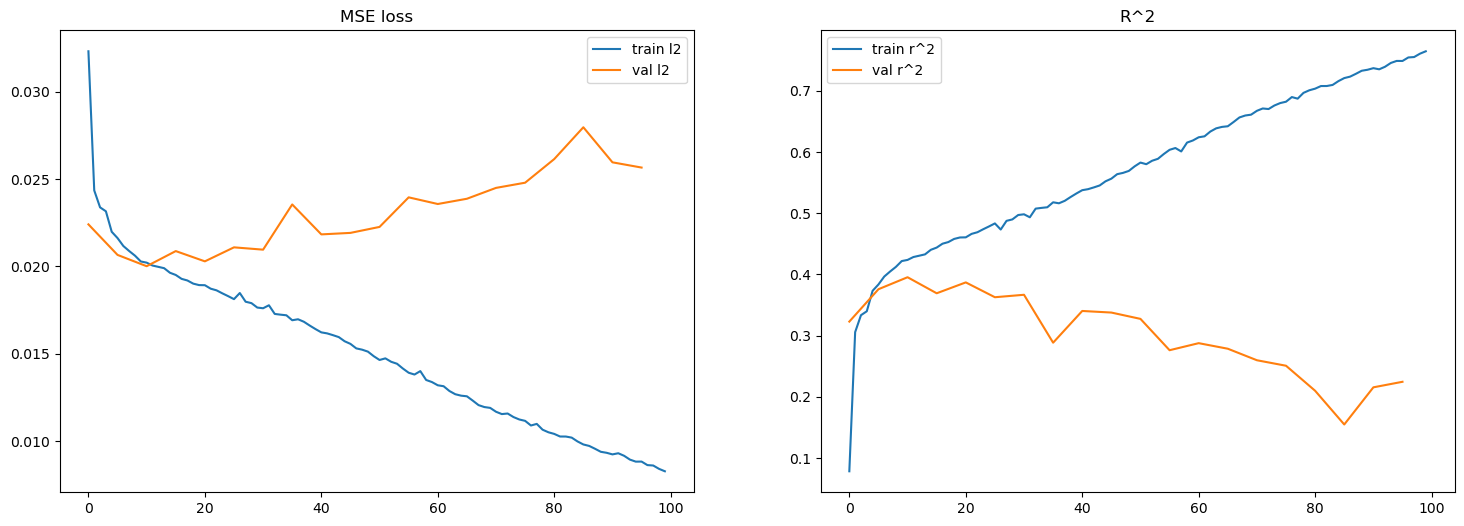

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x_val = np.arange(0, len(trainer.history['loss']), config.val_interval)

plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.plot(trainer.history['l2'], label='train l2')
plt.plot(x_val, trainer.history['val_l2'], label='val l2')
plt.title('MSE loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(trainer.history['r^2'], label='train r^2')
plt.plot(x_val, trainer.history['val_r^2'], label='val r^2')
plt.title('R^2')
plt.legend()

## Vanilla

In [5]:
import numpy as np

alpha = 0.1
eps = 1e-6
max_value = 1.0 - eps

def quantize(preds, probs):
    quantize_scores = []
    for prob, pred in zip(probs, preds):
        cumsum = np.sort(prob)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - pred))
        quantize_scores.append(cumsum[ind])
    return np.asarray(quantize_scores)

def calc_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)

    print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                                prediction_sets[np.arange(m), labels].mean()))
    return prediction_sets.sum(1).mean()


In [119]:
train_predict_out = trainer.predict(model, train_dl)
# train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores'] 
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores'] 
valid_probs = test_predict_out['cls_probs']

# quantize
calib_pred_scores = np.minimum(calib_pred_scores, max_value - eps)
valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
calib_pred_scores = quantize(calib_pred_scores, calib_probs)
valid_pred_scores = quantize(valid_pred_scores, valid_probs)

# conformalize
diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = calib_true_scores - calib_pred_scores

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n, method="higher")

modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat 

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(qhat, n_over_one * 100.))
modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)

calc_mets(valid_probs, modified_valid_pred_scores, test_predict_out['cls_labels'])


Residuals correction is 0.21208650, clip 13.19% of the samples
mean size 2.222 | acc 0.804


2.2221047065044948

In [122]:
import copy

thresh = 0.901237708019801
calib_inds = np.where(calib_pred_scores > thresh)[0]
print(len(calib_inds) / len(calib_pred_scores))

valid_inds = np.where(valid_pred_scores > thresh)[0]
print(len(valid_inds) / len(valid_pred_scores))

# quantize
sub_calib_true_scores = calib_true_scores[calib_inds]
sub_calib_pred_scores = calib_pred_scores[calib_inds]
sub_calib_probs = calib_probs[calib_inds]
sub_valid_pred_scores = valid_pred_scores[valid_inds]
sub_valid_probs = valid_probs[valid_inds]

calc_mets(sub_valid_probs, sub_valid_pred_scores, test_predict_out['cls_labels'][valid_inds])

sub_calib_pred_scores = np.minimum(sub_calib_pred_scores, max_value - eps)
sub_valid_pred_scores = np.minimum(sub_valid_pred_scores, max_value - eps)
sub_calib_pred_scores = quantize(sub_calib_pred_scores, calib_probs)
sub_valid_pred_scores = quantize(sub_valid_pred_scores, valid_probs)

# conformalize
diff = (sub_calib_true_scores - sub_calib_pred_scores) / (max_value - sub_calib_probs.max(1) + eps)

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n, method="higher")

modified_valid_pred_scores = sub_valid_pred_scores + qhat * (max_value - sub_valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat 
n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(qhat, n_over_one * 100.))
modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)

calc_mets(sub_valid_probs, modified_valid_pred_scores, test_predict_out['cls_labels'][valid_inds])

scores = np.full_like(valid_pred_scores, thresh)
scores[valid_inds] = modified_valid_pred_scores
calc_mets(valid_probs, scores, test_predict_out['cls_labels'])


0.3207604179780939
0.32310946589106293
mean size 2.792 | acc 0.966
Residuals correction is 0.19036014, clip 48.36% of the samples
mean size 3.903 | acc 0.910
mean size 2.783 | acc 0.847


2.782919090428345

In [121]:
baseline_mets

{'naive': {'size_mean': 2.6604970914859862,
  'size_std': 1.314009275807639,
  'qhat': 0.9,
  'acc': 0.9457958751983078},
 'aps': {'size_mean': 3.4587519830777365,
  'size_std': 1.8160417808240552,
  'qhat': 0.9863331,
  'acc': 0.8947646747752512},
 'aps_randomized': {'size_mean': 2.3365943945002643,
  'size_std': 1.2242606782474037,
  'qhat': 0.901237708019801,
  'acc': 0.9164463246959281},
 'raps': {'size_mean': 2.658381808566896,
  'size_std': 1.3102360403391458,
  'qhat': 0.8998876264674694,
  'acc': 0.9457958751983078},
 'raps_randomized': {'size_mean': 2.294553146483342,
  'size_std': 1.2340861984985403,
  'qhat': 0.8992933345514224,
  'acc': 0.8987308302485457}}

Text(0.5, 1.0, 'Test mean score correlation')

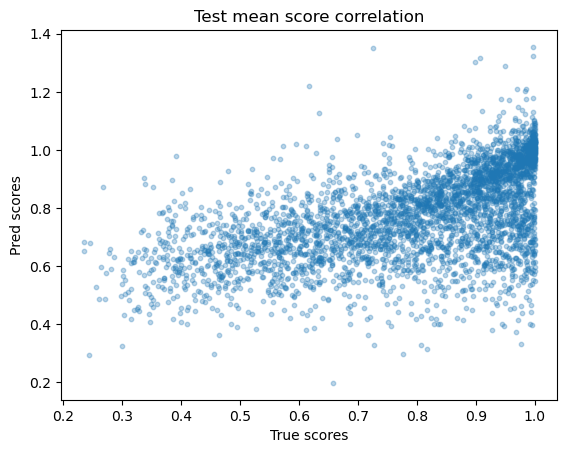

In [31]:
import matplotlib.pyplot as plt
plt.scatter(test_predict_out['true_scores'], test_predict_out['pred_scores'], s=10, alpha=0.3)
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Test mean score correlation')


## Divide to groups

In [32]:
import numpy as np
import math

def get_qhat(calib_true_scores, calib_pred_scores, calib_probs, max_value=max_value, eps=eps):
    diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
    n = len(diff)
    return np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n, method="higher")

def quantize(preds, probs):
    quantize_scores = []
    for prob, pred in zip(probs, preds):
        cumsum = np.sort(prob)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - pred))
        quantize_scores.append(cumsum[ind])
    return np.asarray(quantize_scores)

alpha = 0.1
eps = 1e-8
max_value = 1.0 - eps
thresh = 1. - alpha

train_predict_out = trainer.predict(model, train_dl)
# train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores'] 
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores'] 
valid_probs = test_predict_out['cls_probs']

# quantize
calib_pred_scores = quantize(calib_pred_scores, calib_probs)
valid_pred_scores = quantize(valid_pred_scores, valid_probs)

group1_inds = np.asarray([i for i in range(len(calib_probs)) if calib_pred_scores[i] >= thresh])
group2_inds = np.asarray([i for i in range(len(calib_probs)) if calib_pred_scores[i] < thresh])

high_qhat = get_qhat(calib_true_scores[group1_inds], calib_pred_scores[group1_inds], calib_probs[group1_inds])
low_qhat = get_qhat(calib_true_scores[group2_inds], calib_pred_scores[group2_inds], calib_probs[group2_inds])
print(len(group1_inds), len(group2_inds))
print(low_qhat, high_qhat)

group1_inds = np.asarray([i for i in range(len(valid_probs)) if valid_pred_scores[i] >= thresh])
group2_inds = np.asarray([i for i in range(len(valid_probs)) if valid_pred_scores[i] < thresh])

modified_valid_pred_scores = np.zeros_like(valid_pred_scores)
modified_valid_pred_scores[group1_inds] = valid_pred_scores[group1_inds] + high_qhat * (max_value - valid_probs[group1_inds].max(1) + eps)
modified_valid_pred_scores[group2_inds] = valid_pred_scores[group2_inds] + low_qhat * (max_value - valid_probs[group2_inds].max(1) + eps)

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Clip {:.2f}% of the samples'.format(n_over_one * 100.))
modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)

# predict
m = len(valid_probs)
val_pi = valid_probs.argsort(1)[:, ::-1]
val_srt = np.take_along_axis(valid_probs, val_pi, axis=1).cumsum(axis=1)
prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(modified_valid_pred_scores, 1), val_pi.argsort(axis=1), axis=1)

print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                             prediction_sets[np.arange(m), test_predict_out['cls_labels']].mean()))

12830 26885
0.3086665 0.0
Clip 7.56% of the samples
mean size 2.349 | acc 0.822


In [38]:
psets = []
for p in prediction_sets:
    psets.append(np.where(p)[0].tolist())

In [47]:
n = 103
psets[n], sets[n]

([0, 1, 2, 5, 7], (5, 0, 7, 1, 2, 6))

In [33]:
conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(modified_valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets

{'size_mean': 2.9775251189846643,
 'size_std': 1.9434828949218887,
 'acc': 0.9222633527234267}

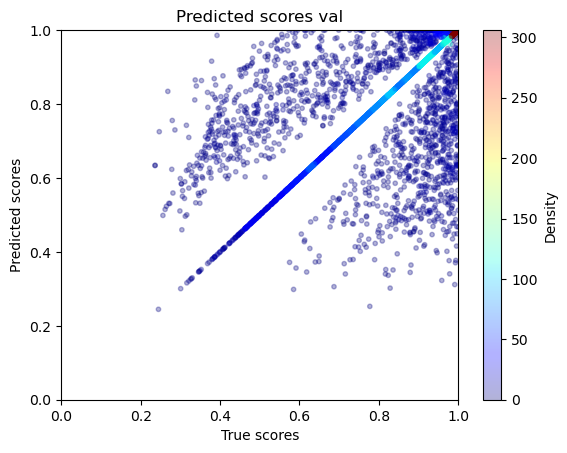

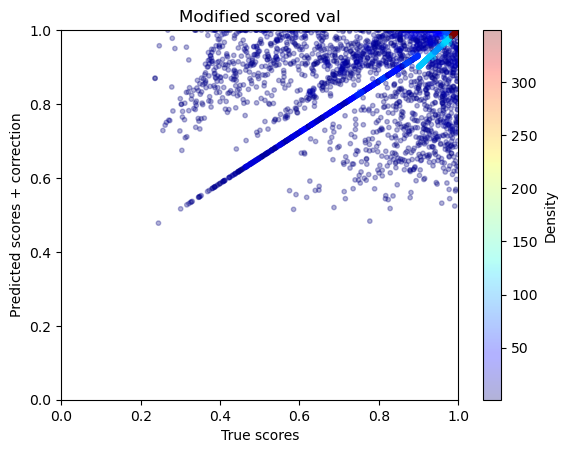

In [34]:
def scatter(x, y, x_label, y_label, title=''):
    density, x_edges, y_edges = np.histogram2d(x, y, bins=50, range=[[0, 1], [0, 1]])

    # plt.plot([0,1], [0,1], color="red")
    plt.scatter(x, y, c=[density[np.digitize(x, x_edges[1:-1]),
                                 np.digitize(y, y_edges[1:-1])]],
                                 cmap='jet', s=10, alpha=0.3)
    plt.colorbar(label='Density')
    plt.xlim([0,1])
    plt.ylim([0,1])
#     plt.scatter(x, y, alpha = 0.1)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()


scatter(valid_true_scores, valid_pred_scores,
        'True scores', 'Predicted scores', 'Predicted scores val')

scatter(valid_true_scores, modified_valid_pred_scores,
        'True scores', 'Predicted scores + correction', 'Modified scored val')


In [22]:
import numpy as np

def quantize_old(all_scores, pred_scores):
    return np.take_along_axis(
        all_scores, np.expand_dims(
            np.abs(all_scores - np.expand_dims(
                pred_scores, 1)).argmin(1), 1), 1).squeeze()

train_predict_out = trainer.predict(model, train_dl)
# train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

max_value = conformal_module.get_max_value(8)
calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_all_scores = np.sort(calib_probs, 1)[:,::-1].cumsum(axis=1)
valid_all_scores = np.sort(valid_probs, 1)[:,::-1].cumsum(axis=1)

calib_pred_scores = quantize_old(calib_all_scores, calib_pred_scores)
valid_pred_scores = quantize_old(valid_all_scores, valid_pred_scores)

alpha = 0.1
eps = 1e-6

diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(modified_valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets

{'size_mean': 2.2501322051824433,
 'size_std': 1.5190814299343511,
 'acc': 0.8577472236911687}

In [41]:
baseline_mets

{'naive': {'size_mean': 2.6604970914859862,
  'size_std': 1.314009275807639,
  'qhat': 0.9,
  'acc': 0.9457958751983078},
 'aps': {'size_mean': 3.4587519830777365,
  'size_std': 1.8160417808240552,
  'qhat': 0.9863331,
  'acc': 0.8947646747752512},
 'aps_randomized': {'size_mean': 2.3365943945002643,
  'size_std': 1.2242606782474037,
  'qhat': 0.901237708019801,
  'acc': 0.9164463246959281},
 'raps': {'size_mean': 2.658381808566896,
  'size_std': 1.3102360403391458,
  'qhat': 0.8998876264674694,
  'acc': 0.9457958751983078},
 'raps_randomized': {'size_mean': 2.294553146483342,
  'size_std': 1.2340861984985403,
  'qhat': 0.8992933345514224,
  'acc': 0.8987308302485457}}

#### Dev quantize

In [15]:
# def quantize(preds, probs)
probs = valid_probs
preds = valid_pred_scores

quantize_scores = []
for prob, pred in zip(probs, preds):
    cumsum = np.sort(prob)[::-1].cumsum()
    ind = np.argmin(np.abs(cumsum - pred))
    quantize_scores.append(cumsum[ind])

    


In [16]:
n = 10
print(preds[n], quantize_scores[n])
print(np.sort(probs[n])[::-1].cumsum())

0.5915667 0.51152796
[0.51152796 0.766361   0.8816781  0.93163323 0.9712175  0.9923567
 0.9978798  1.        ]


#### Old dev

In [6]:
import numpy as np
from conformal import divide, calc_correction_bias

train_predict_out = trainer.predict(model, train_dl)
# train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

max_value = conformal_module.get_max_value(8)
calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_all_scores = np.sort(calib_probs, 1)[:,::-1].cumsum(axis=1)
valid_all_scores = np.sort(valid_probs, 1)[:,::-1].cumsum(axis=1)

# calib_pred_scores = np.clip(calib_pred_scores, a_min=0, a_max=max_value)
# valid_pred_scores = np.clip(valid_pred_scores, a_min=0, a_max=max_value)

# calib_pred_scores = np.maximum(np.minimum(calib_pred_scores, max_value), calib_probs.max(1))
# valid_pred_scores = np.maximum(np.minimum(valid_pred_scores, max_value), valid_probs.max(1))

# calib_pred_scores = randomise_scores(calib_pred_scores, calib_all_scores, max_score=max_value)
# valid_pred_scores = randomise_scores(valid_pred_scores, valid_all_scores, max_score=max_value)

# calib_pred_scores = quantize(calib_all_scores, calib_pred_scores)
# valid_pred_scores = quantize(valid_all_scores, valid_pred_scores)

alpha = 0.1
eps = 1e-6

# diff = calib_true_scores - calib_pred_scores
diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = np.maximum(0., (calib_true_scores - calib_pred_scores) / (max_value - calib_pred_scores + 1e-8))

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

# modified_valid_pred_scores = valid_pred_scores + qhat 
modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_pred_scores)

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_valid_pred_scores = np.clip(modified_valid_pred_scores, a_min=0, a_max=max_value)
# modified_valid_pred_scores = np.maximum(np.minimum(modified_valid_pred_scores, 0.99), valid_probs.max(1))
# modified_valid_pred_scores = np.take_along_axis(valid_all_scores, np.expand_dims(np.abs(valid_all_scores - np.expand_dims(modified_valid_pred_scores, 1)).argmin(1), 1), 1).squeeze()

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets

Residuals correction is 1.71296920, clip 84.21% of the samples


{'size_mean': 1.9177683765203597,
 'size_std': 1.1318925953733805,
 'acc': 0.8553675304071919}

In [77]:
import scipy
import numpy as np
from conformal import divide, calc_correction_bias


def divide(probs, thresh):
    below_indxs = np.where(probs < thresh)[0]
    above_indxs = np.where(probs >= thresh)[0]
    return below_indxs, above_indxs


def get_ent(probs):
    return np.asarray([scipy.stats.entropy(p) for p in probs])

def get_max_prob(probs):
    return np.asarray(probs).max(1)


max_value = conformal_module.get_max_value(8)
calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_all_scores = np.sort(calib_probs, 1)[:,::-1].cumsum(axis=1)
valid_all_scores = np.sort(valid_probs, 1)[:,::-1].cumsum(axis=1)

calib_pred_scores = np.take_along_axis(calib_all_scores, np.expand_dims(np.abs(calib_all_scores - np.expand_dims(calib_pred_scores, 1)).argmin(1), 1), 1).squeeze()
valid_pred_scores = np.take_along_axis(valid_all_scores, np.expand_dims(np.abs(valid_all_scores - np.expand_dims(valid_pred_scores, 1)).argmin(1), 1), 1).squeeze()

alpha = 0.1
ent_thresh = 0.9
diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_all_scores[:, 0] + 1e-6)

calib_below_indxs, calib_above_indxs = divide(get_max_prob(calib_probs), ent_thresh)
qhat_below = calc_correction_bias(diff[calib_below_indxs], alpha)
qhat_above = calc_correction_bias(diff[calib_above_indxs], alpha)

modified_valid_pred_scores = []
for score, prob, min_score in zip(valid_pred_scores, get_ent(valid_probs), valid_all_scores[:, 0]):
    if prob < ent_thresh:
        modified_valid_pred_scores.append(score + qhat_below * (max_value - min_score))
    else:
        modified_valid_pred_scores.append(score + qhat_above * (max_value - min_score))
modified_valid_pred_scores = np.asarray(modified_valid_pred_scores)

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print(f'Qhat [{qhat_below}, {qhat_above}]')

modified_valid_pred_scores = np.maximum(np.minimum(modified_valid_pred_scores, 0.99), valid_probs.max(1))

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(modified_valid_pred_scores, valid_probs)
calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets    


Qhat [0.2764012813568115, 0.0]


{'size_mean': 2.0140137493389743,
 'size_std': 0.92074299075249,
 'acc': 0.8270756213643575}

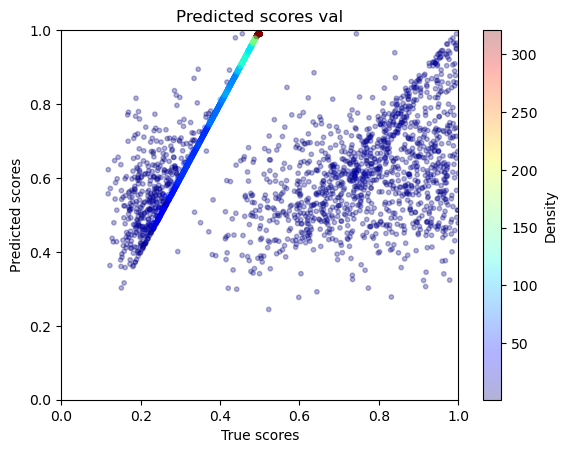

NameError: name 'modified_valid_pred_scores' is not defined

In [46]:
def scatter(x, y, x_label, y_label, title=''):
    density, x_edges, y_edges = np.histogram2d(x, y, bins=50, range=[[0, 1], [0, 1]])

    # plt.plot([0,1], [0,1], color="red")
    plt.scatter(x, y, c=[density[np.digitize(x, x_edges[1:-1]),
                                 np.digitize(y, y_edges[1:-1])]],
                                 cmap='jet', s=10, alpha=0.3)
    plt.colorbar(label='Density')
    plt.xlim([0,1])
    plt.ylim([0,1])
#     plt.scatter(x, y, alpha = 0.1)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

scatter(valid_true_scores, valid_pred_scores,
        'True scores', 'Predicted scores', 'Predicted scores val')

scatter(valid_true_scores, modified_valid_pred_scores,
        'True scores', 'Predicted scores + correction', 'Modified scored val')


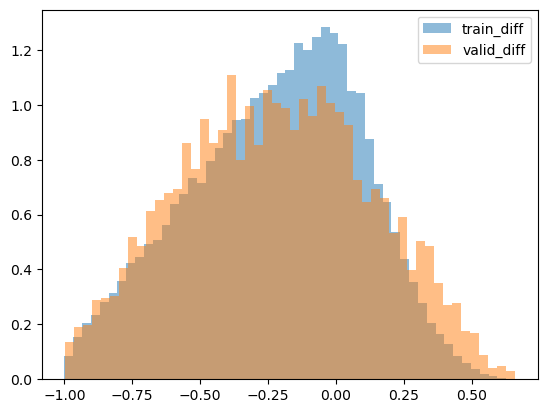

In [69]:
_ = plt.hist(calib_true_scores - calib_pred_scores, bins=50, label='train_diff', alpha=0.5, density=True)
_ = plt.hist(valid_true_scores - valid_pred_scores, bins=50, label='valid_diff', alpha=0.5, density=True)
plt.legend()

# 1NN baseline model

In [6]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.use_score_clipping = False 

utils.seed_everything(config.seed)

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(train_dl, valid_dl, alpha=config.alpha, k_raps=config.k_raps)


  2%|▏         | 2/100 [00:01<01:36,  1.02it/s]


In [102]:
from sklearn.metrics.pairwise import cosine_similarity

s = cosine_similarity(valid_dl.dataset.cls_probs, train_dl.dataset.cls_probs)
valid_ind2max_train_ind = s.argmax(1)
valid_pred_scores = train_dl.dataset.scores[valid_ind2max_train_ind].flatten().numpy()

s = cosine_similarity(test_dl.dataset.cls_probs, train_dl.dataset.cls_probs)
test_ind2max_train_ind = s.argmax(1)
test_pred_scores = train_dl.dataset.scores[test_ind2max_train_ind].flatten().numpy()

calc_mets(test_dl.dataset.cls_probs.numpy(), test_pred_scores, test_dl.dataset.cls_labels.numpy())


mean size 1.143 | acc 0.544


1.1425171866737176

In [99]:
# valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
# test_pred_scores = np.minimum(test_pred_scores, max_value - eps)
valid_pred_scores = quantize(valid_pred_scores, valid_dl.dataset.cls_probs.numpy())
test_pred_scores = quantize(test_pred_scores, test_dl.dataset.cls_probs.numpy())

diff = (valid_dl.dataset.scores - valid_pred_scores) / (1. - valid_dl.dataset.cls_probs.numpy().max(1) + eps)
n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

modified_test_pred_scores = test_pred_scores + qhat * (1. - test_dl.dataset.cls_probs.numpy().max(1) + eps)

n_over_one = (modified_test_pred_scores >= 1.).sum() / len(modified_test_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_test_pred_scores = np.minimum(modified_test_pred_scores, 1.)
calc_mets(test_dl.dataset.cls_probs.numpy(), modified_test_pred_scores, test_dl.dataset.cls_labels.numpy())

Residuals correction is 0.00000000, clip 11.71% of the samples
mean size 3.718 | acc 0.939


3.7181385510312004

# k-NN model

In [62]:
from sklearn.metrics.pairwise import cosine_similarity

k = 5
def get_scores(val_mat, train_mat, train_scores, k):
    scores = cosine_similarity(val_mat, train_mat)
    kinds = np.argsort(scores, axis=1)[:,:k]
    return train_scores[kinds].mean(1)

val_mat = valid_dl.dataset.cls_probs.numpy()
test_mat = test_dl.dataset.cls_probs.numpy()

train_mat = train_dl.dataset.cls_probs.numpy()
train_scores = train_dl.dataset.scores.numpy()

valid_pred_scores = get_scores(val_mat, train_mat, train_scores, k)
test_pred_scores = get_scores(test_mat, train_mat, train_scores, k)

calc_mets(test_dl.dataset.cls_probs.numpy(), test_pred_scores, test_dl.dataset.cls_labels.numpy())


mean size 2.780 | acc 0.721


2.7797461660497094

In [63]:
# valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
# test_pred_scores = np.minimum(test_pred_scores, max_value - eps)

valid_pred_scores = quantize(valid_pred_scores, valid_dl.dataset.cls_probs.numpy())
test_pred_scores = quantize(test_pred_scores, test_dl.dataset.cls_probs.numpy())

diff = (valid_dl.dataset.scores - valid_pred_scores) / (1. - valid_dl.dataset.cls_probs.numpy().max(1) + eps)
n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

modified_test_pred_scores = test_pred_scores + qhat * (1. - test_dl.dataset.cls_probs.numpy().max(1) + eps)

n_over_one = (modified_test_pred_scores >= 1.).sum() / len(modified_test_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_test_pred_scores = np.minimum(modified_test_pred_scores, 1.)
calc_mets(test_dl.dataset.cls_probs.numpy(), modified_test_pred_scores, test_dl.dataset.cls_labels.numpy())

Residuals correction is 0.00000000, clip 10.39% of the samples
mean size 3.495 | acc 0.937


3.4949762030671603